In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle

### Functions

In [2]:
def plot_bk_distributions(df_grouped, str_col):
    # create dict
    dict_tmp = dict(zip(df_grouped['bk'], df_grouped['count']))
    int_count_nobk = dict_tmp['No BK']
    int_count_bk = dict_tmp['BK']
    # title
    int_nrows = df_grouped['count'].sum()
    str_title = f"""
    Distribution of {str_col} by BK (N = {int_nrows})
    Counts: NoBK = {int_count_nobk}; BK = {int_count_bk}
    """
    # create dict
    dict_tmp = dict(zip(df_grouped['bk'], df_grouped[str_col]))
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    # iterate and plot
    for str_bktype, list_values in tqdm(dict_tmp.items()):
        flt_mdn = np.median(list_values)
        str_label = f'{str_bktype} - {flt_mdn:0.4f}'
        sns.kdeplot(list_values, ax=ax, label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [3]:
def plot_bk_type_distributions(df_grouped, str_col):
    # create dict
    dict_tmp = dict(zip(df_grouped['intType'], df_grouped['count']))
    int_count_nobk = dict_tmp['nan']
    int_count_bk7 = dict_tmp['7.0']
    int_count_bk13 = dict_tmp['13.0']
    # title
    int_nrows = df_grouped['count'].sum()
    str_title = f"""
    Distribution of {str_col} by BK Type (N = {int_nrows})
    Counts: NoBK = {int_count_nobk}; 7.0 = {int_count_bk7}; 13.0 = {int_count_bk13}
    """
    # create dict
    dict_tmp = dict(zip(df_grouped['intType'], df_grouped[str_col]))
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    # iterate and plot
    for str_bktype, list_values in tqdm(dict_tmp.items()):
        flt_mdn = np.median(list_values)
        str_label = f'{str_bktype} - {flt_mdn:0.4f}'
        sns.kdeplot(list_values, ax=ax, label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [4]:
def plot_tier_distributions(df_grouped, str_col):
    # create dict
    dict_tmp = dict(zip(df_grouped['tier'], df_grouped['count']))
    int_count_a1 = dict_tmp['A1']
    int_count_a = dict_tmp['A']
    int_count_b = dict_tmp['B']
    int_count_c = dict_tmp['C']
    int_count_d = dict_tmp['D']
    int_count_decline = dict_tmp['Decline']
    # title
    int_nrows = df_grouped['count'].sum()
    str_title = f"""
    Distribution of {str_col} by Tier (N = {int_nrows})
    Counts: A1 = {int_count_a1}; A = {int_count_a}; B = {int_count_b}; C = {int_count_c}; D = {int_count_d}; Decline = {int_count_decline}
    """
    # create dict
    dict_tmp = dict(zip(df_grouped['tier'], df_grouped[str_col]))
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    # iterate and plot
    for str_bktype, list_values in tqdm(dict_tmp.items()):
        flt_mdn = np.median(list_values)
        str_label = f'{str_bktype} - {flt_mdn:0.4f}'
        sns.kdeplot(list_values, ax=ax, label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [5]:
def get_descriptives(df, str_col):
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    df = pd.DataFrame({
        'Statistic': ['Minimum','Maximum','Mean','SD','Median'],
        'Value': [flt_min, flt_max, flt_mean, flt_sd, flt_mdn],
    })
    return df

In [6]:
def get_tier(flt_ecnl, dict_tiers):
    if flt_ecnl < dict_tiers['A1']:
        return 'A1'
    elif flt_ecnl < dict_tiers['A']:
        return 'A'
    elif flt_ecnl < dict_tiers['B']:
        return 'B'
    elif flt_ecnl < dict_tiers['C']:
        return 'C'
    elif flt_ecnl < dict_tiers['D']:
        return 'D'
    else:
        return 'Decline'

### Constants

In [7]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# clip ecnl
bool_clip_ecnl = True
# loss factor (24 to 72)
#flt_factor_loss = 2.3612 # from loss forecasting
flt_factor_loss = 1
# multiply factor
bool_multiply_factor = True

Project: 20231010-gen-xii


### Get target ECNL factor

In [8]:
str_filename = 'flt_best_factor.pkl'
str_local_path = f'../../02_get_thresholds/output/{str_filename}'
flt_factor_target_ecnl = pickle.load(open(str_local_path, 'rb'))
#flt_factor_target_ecnl = 1
print(f'Best factor: {flt_factor_target_ecnl:0.4f}')

Best factor: 1.5075


### Get all scores

In [9]:
str_filename = 'df_scores.gzip'
str_uri = f's3://{str_project}/12_dark_scoring/01_pull_scores_from_db/{str_filename}'
df = pd.read_parquet(str_uri)
# multiply lgd by factor
if bool_multiply_factor:
    df['fltDebtor_Score_lgd'] = df['fltDebtor_Score_lgd'] * flt_factor_loss
    # new ecnl
    df['fltDebtorScore'] = df['fltDebtor_Score_pd'] * df['fltDebtor_Score_lgd']
    # to get to target
    df['fltDebtorScore'] = df['fltDebtorScore'] * flt_factor_target_ecnl
else:
    pass
# clip ecnl
if bool_clip_ecnl:
    df['fltDebtorScore'] = df['fltDebtorScore'].clip(lower=0)
else:
    pass
flt_mean = df['fltDebtorScore'].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
df

Mean ECNL: 0.2613


,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.215919,0.366327,0.390988,0.054941,1
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.012398,0.300804,0.027340,0.085813,1
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.197235,0.389506,0.335900,0.334481,1
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.208379,0.418457,0.330326,0.445710,1
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,0.472437,0.584907,0.535794,0.407639,1
...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.222831,0.485824,0.304254,0.215153,1
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.100818,0.448009,0.149277,0.261241,1
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.275033,0.450335,0.405126,0.383911,1
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.066186,0.392720,0.111795,0.196025,1


### Get BK type

In [10]:
str_filename = 'df_scores.gzip'
str_uri = f's3://{str_project}/12_dark_scoring/03_analysis/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
dict_rename = {
    'bigaccountid': 'bigAccountId',
}
df_tmp.rename(columns=dict_rename, inplace=True)
#df_tmp.drop_duplicates(subset=['bigAccountId'], keep='last', inplace=True)
df_tmp

,bigAccountId,intType
0,7034142,13
1,7086394,13
2,7089886,7
3,7090584,7
4,7090721,13
...,...,...
1482,7704145,7
1483,7704200,7
1484,7704233,7
1485,7704277,7


### Join

In [11]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='left'
)
df['intType'] = df['intType'].astype(str)
df['bk'] = df['intType'].apply(
    lambda x: 'BK' if x in ['7.0', '13.0'] else 'No BK',
)

df['ad_minus_pd'] = df['fltDebtor_Score_ad'] - df['fltDebtor_Score_pd']
df['count'] = 1
df

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,intType,bk,ad_minus_pd,count
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.215919,0.366327,0.390988,0.054941,1,7.0,BK,-0.336047,1
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.012398,0.300804,0.027340,0.085813,1,nan,No BK,0.058473,1
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.197235,0.389506,0.335900,0.334481,1,nan,No BK,-0.001419,1
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.208379,0.418457,0.330326,0.445710,1,nan,No BK,0.115384,1
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,0.472437,0.584907,0.535794,0.407639,1,nan,No BK,-0.128155,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.222831,0.485824,0.304254,0.215153,1,nan,No BK,-0.089101,1
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.100818,0.448009,0.149277,0.261241,1,nan,No BK,0.111964,1
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.275033,0.450335,0.405126,0.383911,1,nan,No BK,-0.021215,1
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.066186,0.392720,0.111795,0.196025,1,nan,No BK,0.084230,1


### Get tier

In [12]:
# get dict_tiers
str_filename = 'df_tiers.csv'
str_local_path = f'../../02_get_thresholds/output/{str_filename}'
df_tiers = pd.read_csv(str_local_path)
dict_tiers = dict(zip(df_tiers['tier'], df_tiers['fltDebtorScore']))
print('Tiers:')
print(dict_tiers)

# get tier
df['tier'] = df['fltDebtorScore'].apply(
    lambda x: get_tier(
        flt_ecnl=x,
        dict_tiers=dict_tiers,
    ),
)
df

Tiers:
{'A': 0.1331368967462644, 'A1': 0.0883267030820658, 'B': 0.2375062000386774, 'C': 0.2791745818869392, 'D': 0.3104102272695371}


,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,intType,bk,ad_minus_pd,count,tier
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.215919,0.366327,0.390988,0.054941,1,7.0,BK,-0.336047,1,B
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.012398,0.300804,0.027340,0.085813,1,nan,No BK,0.058473,1,A1
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.197235,0.389506,0.335900,0.334481,1,nan,No BK,-0.001419,1,B
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.208379,0.418457,0.330326,0.445710,1,nan,No BK,0.115384,1,B
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,0.472437,0.584907,0.535794,0.407639,1,nan,No BK,-0.128155,1,Decline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.222831,0.485824,0.304254,0.215153,1,nan,No BK,-0.089101,1,B
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.100818,0.448009,0.149277,0.261241,1,nan,No BK,0.111964,1,A
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.275033,0.450335,0.405126,0.383911,1,nan,No BK,-0.021215,1,C
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.066186,0.392720,0.111795,0.196025,1,nan,No BK,0.084230,1,A1


### Descriptive statistics

In [13]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    print(f'{str_col}:')
    df_tmp = get_descriptives(
        df=df, 
        str_col=str_col,
    )
    print(df_tmp)
    print()

fltDebtor_Score_ad:
  Statistic     Value
0   Minimum  0.016387
1   Maximum  0.861995
2      Mean  0.356278
3        SD  0.125843
4    Median  0.355681

fltDebtor_Score_pd:
  Statistic     Value
0   Minimum  0.017553
1   Maximum  0.934742
2      Mean  0.389439
3        SD  0.174544
4    Median  0.377814

ad_minus_pd:
  Statistic     Value
0   Minimum -0.559331
1   Maximum  0.527498
2      Mean -0.033161
3        SD  0.124972
4    Median -0.021668

fltDebtor_Score_lgd:
  Statistic     Value
0   Minimum  0.135032
1   Maximum  0.649697
2      Mean  0.425856
3        SD  0.076462
4    Median  0.430867

fltDebtorScore:
  Statistic     Value
0   Minimum  0.006959
1   Maximum  0.881884
2      Mean  0.261324
3        SD  0.143804
4    Median  0.242499



### Show BK frequencies

In [14]:
ser_freq = df['bk'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['BK', 'Proportion']
df_freq

,BK,Proportion
0,No BK,0.93126
1,BK,0.06874


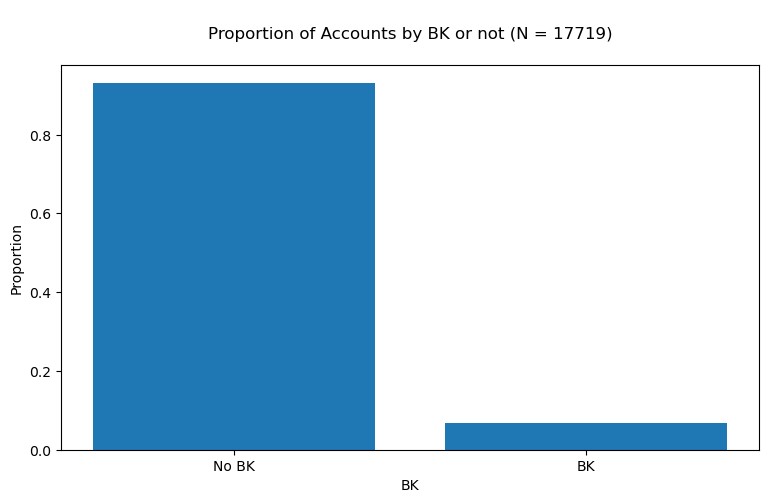

In [15]:
int_nrows = df.shape[0]
str_title = f"""
Proportion of Accounts by BK or not (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('BK')
ax.set_ylabel('Proportion')
ax.bar(df_freq['BK'], df_freq['Proportion'])
plt.show()

### Show BK type frequencies

In [16]:
ser_freq = df['intType'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['BK Type', 'Proportion']
df_freq

,BK Type,Proportion
0,nan,0.931260
1,7.0,0.041199
2,13.0,0.027541


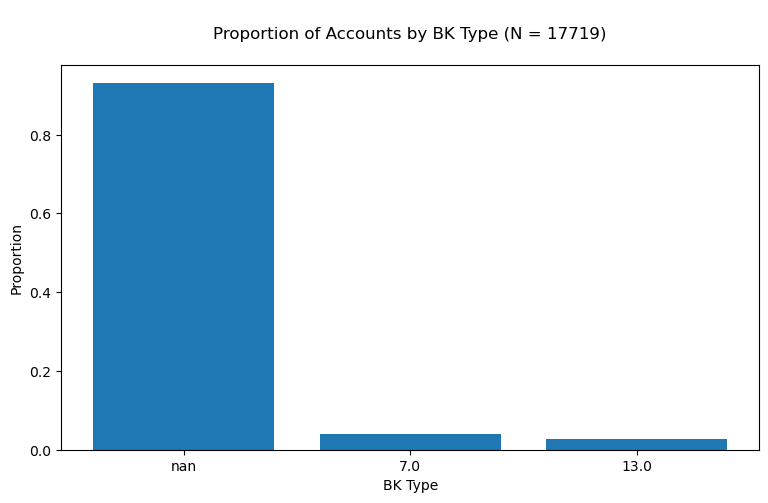

In [17]:
int_nrows = df.shape[0]
str_title = f"""
Proportion of Accounts by BK Type (N = {int_nrows})
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('BK Type')
ax.set_ylabel('Proportion')
ax.bar(df_freq['BK Type'], df_freq['Proportion'])
plt.show()

### Distributions of scores by BK or not

In [18]:
df_grouped = df.groupby(by='bk', as_index=False).agg({
    'fltDebtor_Score_ad': lambda x: list(x),
    'fltDebtor_Score_pd': lambda x: list(x),
    'ad_minus_pd': lambda x: list(x),
    'fltDebtor_Score_lgd': lambda x: list(x),
    'fltDebtorScore': lambda x: list(x),
    'count': 'sum',
})
df_grouped

,bk,fltDebtor_Score_ad,fltDebtor_Score_pd,ad_minus_pd,fltDebtor_Score_lgd,fltDebtorScore,count
0,BK,"[0.054941, 0.311665, 0.024082, 0.082569, 0.039...","[0.390988, 0.661512, 0.123174, 0.158925, 0.187...","[-0.336047, -0.34984699999999996, -0.099092000...","[0.366327, 0.517805, 0.339537, 0.271866, 0.331...","[0.21591948786832435, 0.516372909976937, 0.063...",1218
1,No BK,"[0.085813, 0.334481, 0.44571, 0.407639, 0.3772...","[0.02734, 0.3359, 0.330326, 0.535794, 0.402355...","[0.058473, -0.0014190000000000036, 0.115383999...","[0.300804, 0.389506, 0.418457, 0.584907, 0.426...","[0.012397713641801802, 0.19723484333573574, 0....",16501


100%|██████████| 2/2 [00:00<00:00, 13.98it/s]


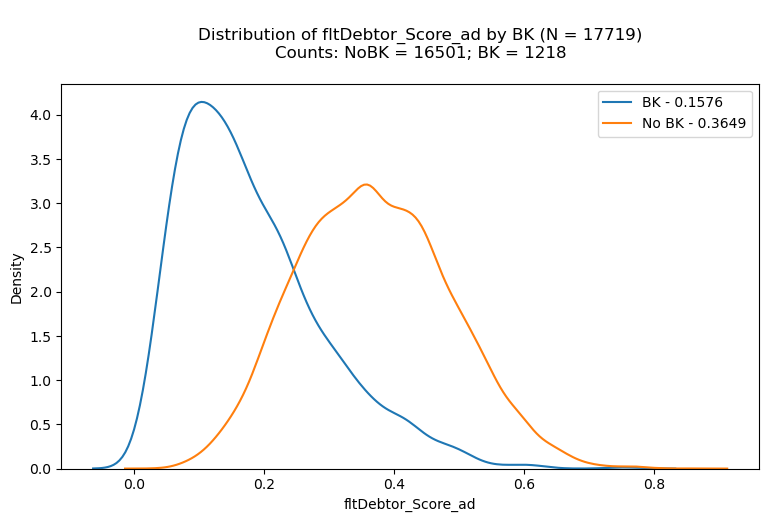

100%|██████████| 2/2 [00:00<00:00,  9.48it/s]


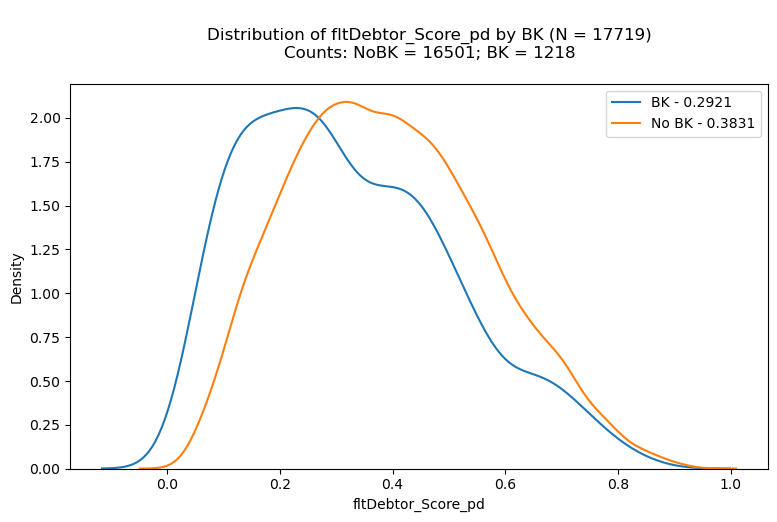

100%|██████████| 2/2 [00:00<00:00,  8.46it/s]


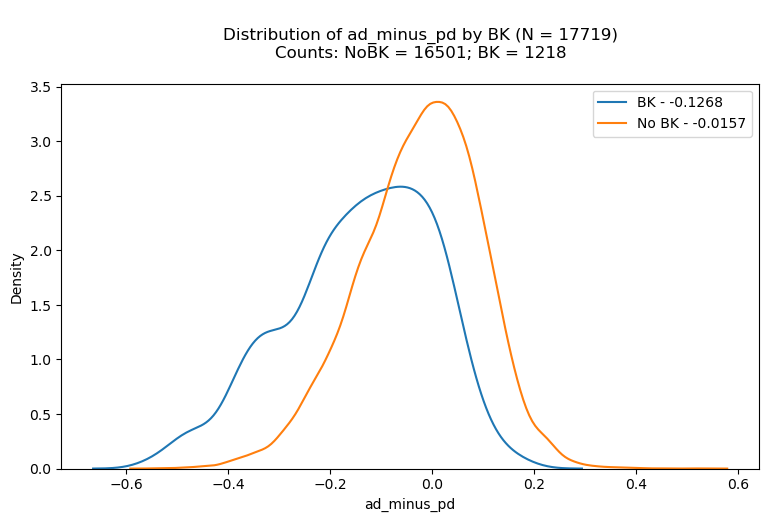

100%|██████████| 2/2 [00:00<00:00, 13.07it/s]


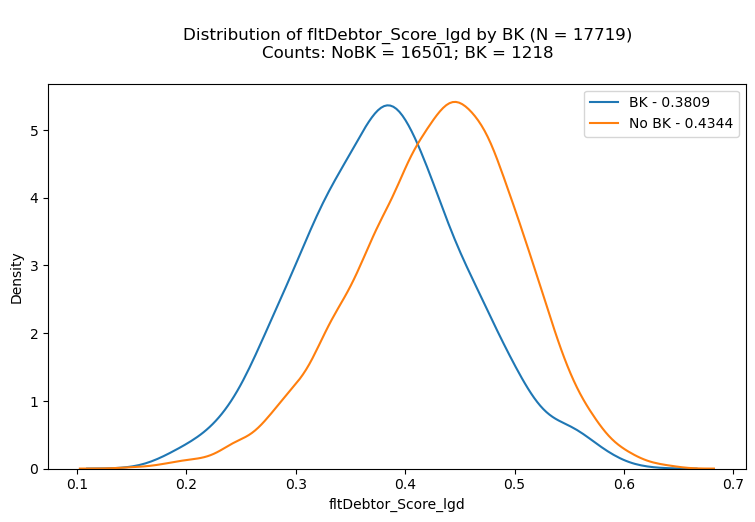

100%|██████████| 2/2 [00:00<00:00, 14.14it/s]


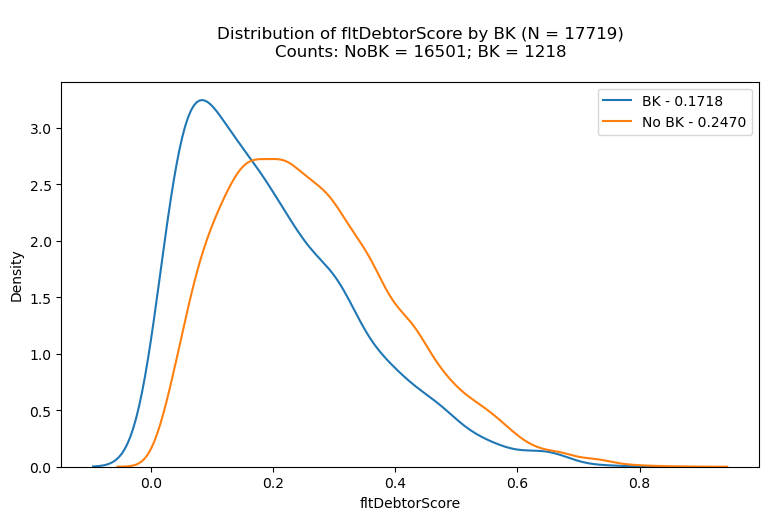

In [19]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    plot_bk_distributions(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

### Distributions of scores by BK type

In [20]:
df_grouped = df.groupby(by='intType', as_index=False).agg({
    'fltDebtor_Score_ad': lambda x: list(x),
    'fltDebtor_Score_pd': lambda x: list(x),
    'ad_minus_pd': lambda x: list(x),
    'fltDebtor_Score_lgd': lambda x: list(x),
    'fltDebtorScore': lambda x: list(x),
    'count': 'sum',
})
df_grouped

,intType,fltDebtor_Score_ad,fltDebtor_Score_pd,ad_minus_pd,fltDebtor_Score_lgd,fltDebtorScore,count
0,13.0,"[0.082569, 0.087328, 0.14436, 0.219648, 0.2629...","[0.158925, 0.137083, 0.29241, 0.385961, 0.1500...","[-0.07635600000000001, -0.04975500000000001, -...","[0.271866, 0.266001, 0.353961, 0.399054, 0.382...","[0.06513382772702704, 0.054970077992990994, 0....",488
1,7.0,"[0.054941, 0.311665, 0.024082, 0.039445, 0.191...","[0.390988, 0.661512, 0.123174, 0.187702, 0.702...","[-0.336047, -0.34984699999999996, -0.099092000...","[0.366327, 0.517805, 0.339537, 0.331276, 0.484...","[0.21591948786832435, 0.516372909976937, 0.063...",730
2,nan,"[0.085813, 0.334481, 0.44571, 0.407639, 0.3772...","[0.02734, 0.3359, 0.330326, 0.535794, 0.402355...","[0.058473, -0.0014190000000000036, 0.115383999...","[0.300804, 0.389506, 0.418457, 0.584907, 0.426...","[0.012397713641801802, 0.19723484333573574, 0....",16501


100%|██████████| 3/3 [00:00<00:00, 19.30it/s]


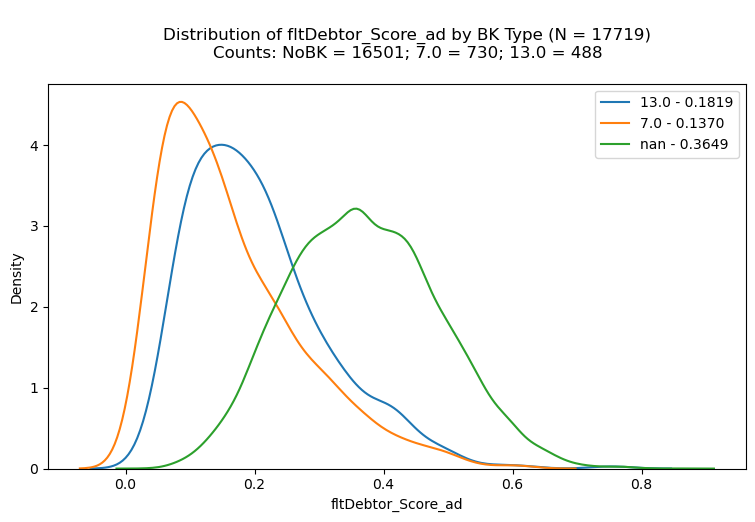

100%|██████████| 3/3 [00:00<00:00, 20.81it/s]


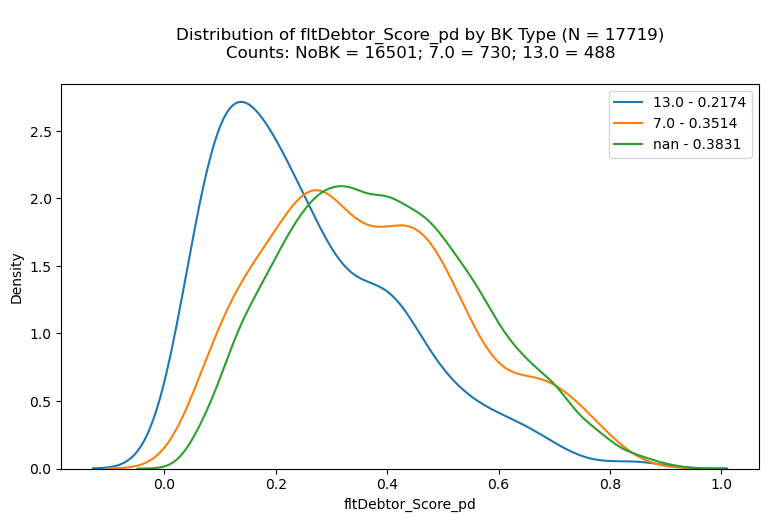

100%|██████████| 3/3 [00:00<00:00, 20.05it/s]


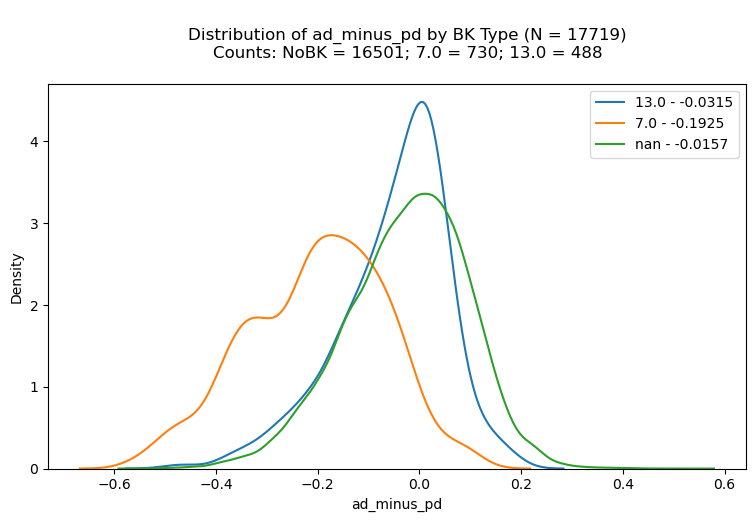

100%|██████████| 3/3 [00:00<00:00, 18.20it/s]


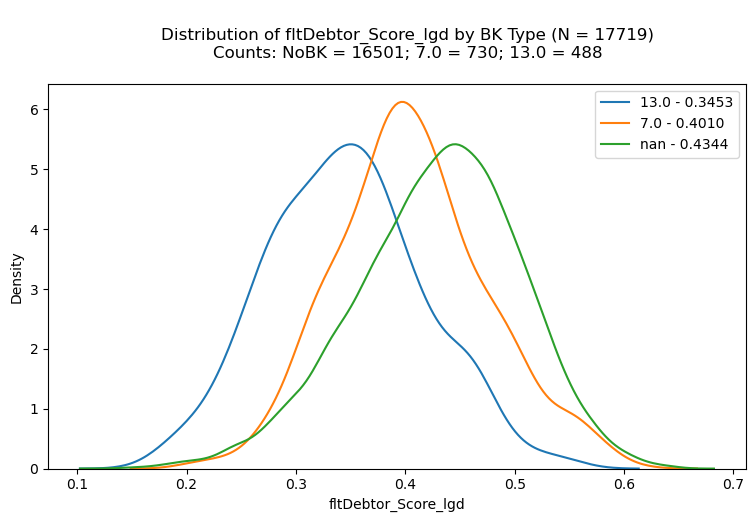

100%|██████████| 3/3 [00:00<00:00, 17.98it/s]


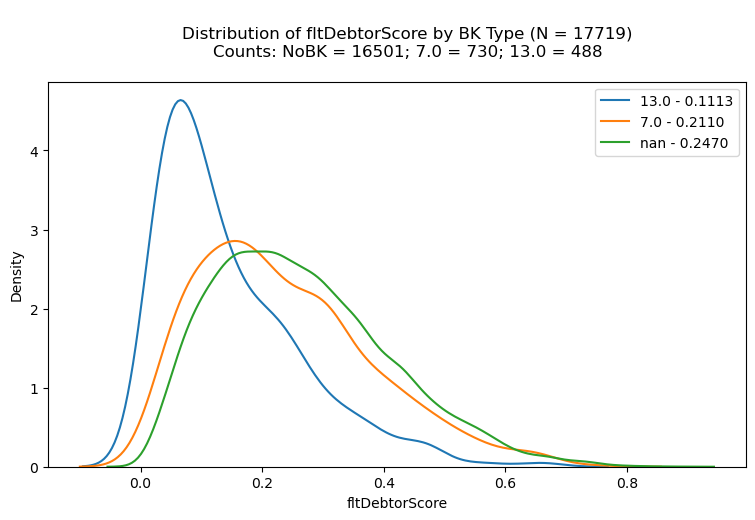

In [21]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    plot_bk_type_distributions(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

### Show tier frequencies

In [22]:
df_grouped = df.groupby(by='tier', as_index=False).agg({
    'fltDebtor_Score_ad': lambda x: list(x),
    'fltDebtor_Score_pd': lambda x: list(x),
    'ad_minus_pd': lambda x: list(x),
    'fltDebtor_Score_lgd': lambda x: list(x),
    'fltDebtorScore': lambda x: list(x),
    'count': 'sum',
})
df_grouped

,tier,fltDebtor_Score_ad,fltDebtor_Score_pd,ad_minus_pd,fltDebtor_Score_lgd,fltDebtorScore,count
0,A,"[0.233025, 0.271919, 0.267834, 0.039445, 0.198...","[0.204516, 0.200581, 0.226473, 0.187702, 0.267...","[0.028509000000000007, 0.07133800000000001, 0....","[0.420981, 0.40173, 0.351805, 0.331276, 0.2996...","[0.12979240179697296, 0.12147405818396396, 0.1...",1854
1,A1,"[0.085813, 0.024082, 0.082569, 0.341022, 0.189...","[0.02734, 0.123174, 0.158925, 0.113299, 0.2065...","[0.058473, -0.09909200000000001, -0.0763560000...","[0.300804, 0.339537, 0.271866, 0.29083, 0.2564...","[0.012397713641801802, 0.06304717561524324, 0....",1776
2,B,"[0.054941, 0.334481, 0.44571, 0.322275, 0.3521...","[0.390988, 0.3359, 0.330326, 0.316169, 0.28657...","[-0.336047, -0.0014190000000000036, 0.11538399...","[0.366327, 0.389506, 0.418457, 0.327315, 0.346...","[0.21591948786832435, 0.19723484333573574, 0.2...",5000
3,C,"[0.377257, 0.398373, 0.498557, 0.343187, 0.478...","[0.402355, 0.398746, 0.423469, 0.386601, 0.361...","[-0.02509800000000001, -0.0003730000000000122,...","[0.426687, 0.445931, 0.376627, 0.465572, 0.502...","[0.2588083580728829, 0.2680547377418979, 0.240...",1847
4,D,"[0.537065, 0.394848, 0.506781, 0.587673, 0.362...","[0.442814, 0.47333, 0.402132, 0.447558, 0.4936...","[0.09425100000000003, -0.078482, 0.10464900000...","[0.452409, 0.424309, 0.496828, 0.454977, 0.416...","[0.3020035601827387, 0.3027650625914114, 0.301...",1319
5,Decline,"[0.407639, 0.311665, 0.537442, 0.342527, 0.524...","[0.535794, 0.661512, 0.478819, 0.553296, 0.518...","[-0.12815500000000002, -0.34984699999999996, 0...","[0.584907, 0.517805, 0.470505, 0.484538, 0.451...","[0.4724372669709189, 0.516372909976937, 0.3396...",5923


100%|██████████| 6/6 [00:00<00:00, 28.00it/s]


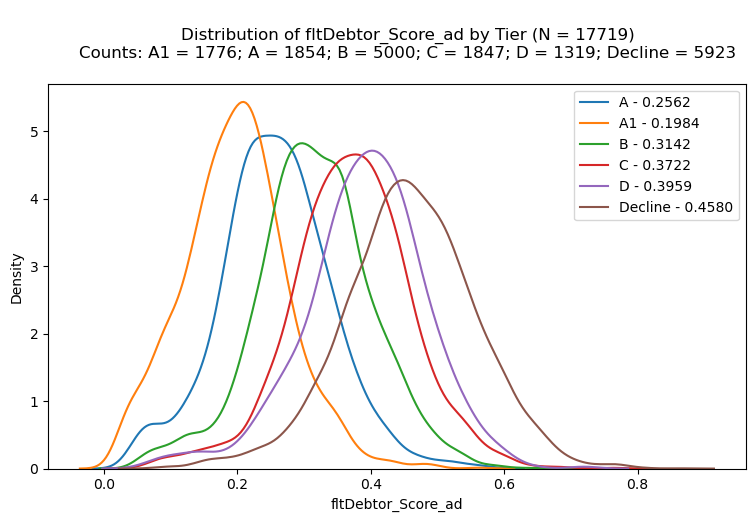

100%|██████████| 6/6 [00:00<00:00, 31.77it/s]


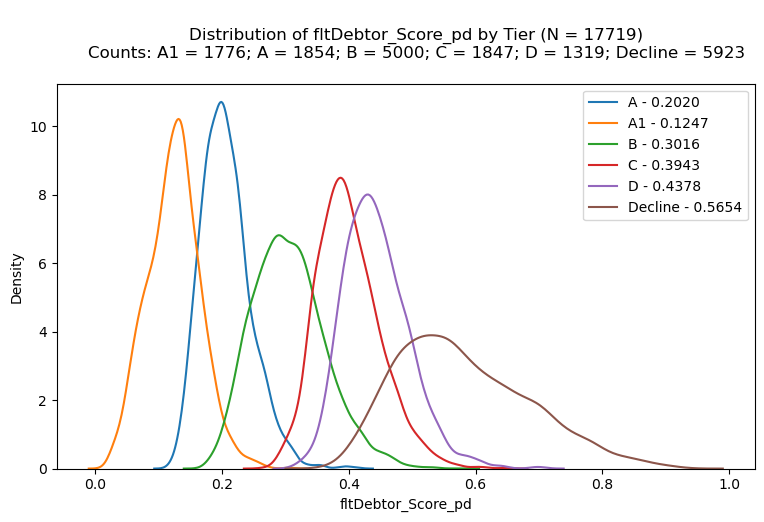

100%|██████████| 6/6 [00:00<00:00, 31.52it/s]


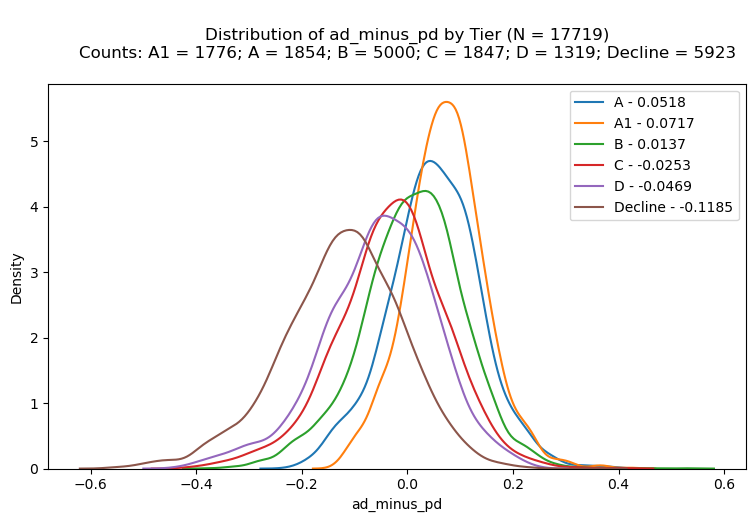

100%|██████████| 6/6 [00:00<00:00, 25.59it/s]


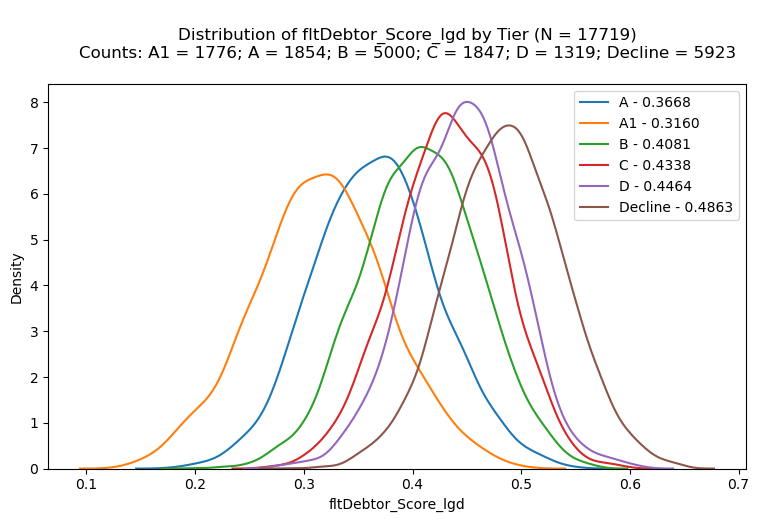

100%|██████████| 6/6 [00:00<00:00, 35.35it/s]


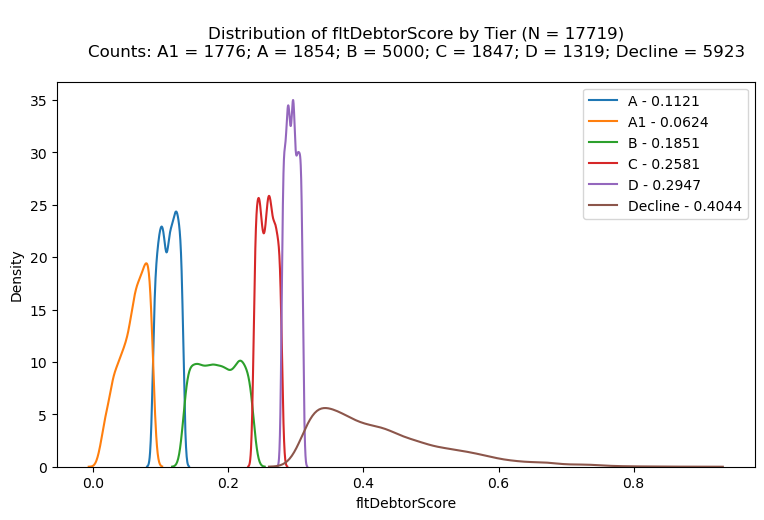

In [23]:
list_str_col = [
    'fltDebtor_Score_ad',
    'fltDebtor_Score_pd',
    'ad_minus_pd',
    'fltDebtor_Score_lgd',
    'fltDebtorScore',
]
for str_col in list_str_col:
    plot_tier_distributions(
        df_grouped=df_grouped, 
        str_col=str_col,
    )

### BK Type and Tier

In [24]:
df['tier_bk'] = df.apply(
    lambda x: f'{x["tier"]} - {x["bk"]}',
    axis=1,
)
df

,bigAccountId,dtmStampCreation,dtmApproved,dtmFunded,strScoreCardVersion,fltDebtorScore,fltDebtor_Score_lgd,fltDebtor_Score_pd,fltDebtor_Score_ad,RowNum,intType,bk,ad_minus_pd,count,tier,tier_bk
0,7657064,2024-03-14 05:58:34.890,2024-03-14 05:58:54.893,NaT,genxii_v2,0.215919,0.366327,0.390988,0.054941,1,7.0,BK,-0.336047,1,B,B - BK
1,7657065,2024-03-14 06:19:01.423,NaT,NaT,genxii_v2,0.012398,0.300804,0.027340,0.085813,1,nan,No BK,0.058473,1,A1,A1 - No BK
2,7657070,2024-03-14 06:52:05.273,2024-03-14 06:52:19.663,NaT,genxii_v2,0.197235,0.389506,0.335900,0.334481,1,nan,No BK,-0.001419,1,B,B - No BK
3,7657071,2024-03-14 06:56:01.100,NaT,NaT,genxii_v2,0.208379,0.418457,0.330326,0.445710,1,nan,No BK,0.115384,1,B,B - No BK
4,7657072,2024-03-14 06:57:17.540,NaT,NaT,genxii_v2,0.472437,0.584907,0.535794,0.407639,1,nan,No BK,-0.128155,1,Decline,Decline - No BK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17714,7704331,2024-03-24 20:13:01.587,NaT,NaT,genxii_v2,0.222831,0.485824,0.304254,0.215153,1,nan,No BK,-0.089101,1,B,B - No BK
17715,7704333,2024-03-24 20:47:55.387,2024-03-24 20:48:17.837,NaT,genxii_v2,0.100818,0.448009,0.149277,0.261241,1,nan,No BK,0.111964,1,A,A - No BK
17716,7704334,2024-03-24 20:51:22.957,NaT,NaT,genxii_v2,0.275033,0.450335,0.405126,0.383911,1,nan,No BK,-0.021215,1,C,C - No BK
17717,7704336,2024-03-24 21:06:41.647,2024-03-24 21:07:09.940,NaT,genxii_v2,0.066186,0.392720,0.111795,0.196025,1,nan,No BK,0.084230,1,A1,A1 - No BK


In [25]:
df_grouped = df.groupby(by='tier_bk', as_index=False).agg({
    'fltDebtor_Score_ad': 'median',
    'fltDebtor_Score_pd': 'median',
    'ad_minus_pd': 'median',
    'fltDebtor_Score_lgd': 'median',
    'fltDebtorScore': 'median',
    'count': 'sum',
})
df_grouped.sort_values(by='fltDebtorScore', ascending=True, inplace=True)
df_grouped

,tier_bk,fltDebtor_Score_ad,fltDebtor_Score_pd,ad_minus_pd,fltDebtor_Score_lgd,fltDebtorScore,count
2,A1 - BK,0.095224,0.113515,-0.008277,0.303044,0.052985,302
3,A1 - No BK,0.211357,0.127319,0.085348,0.319864,0.063862,1474
0,A - BK,0.129748,0.209861,-0.083636,0.347411,0.110184,180
1,A - No BK,0.262968,0.200850,0.060381,0.368839,0.112240,1674
4,B - BK,0.156493,0.307085,-0.158092,0.387449,0.181024,322
5,B - No BK,0.319881,0.301415,0.020429,0.409622,0.185408,4678
6,C - BK,0.187508,0.413307,-0.217065,0.410436,0.257398,93
7,C - No BK,0.376347,0.393002,-0.019965,0.435334,0.258168,1754
9,D - No BK,0.402241,0.436504,-0.040448,0.447526,0.294693,1246
8,D - BK,0.194190,0.458178,-0.259359,0.432708,0.296542,73


/tmp/ipykernel_14484/2844592156.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_grouped['tier_bk'], rotation=90)


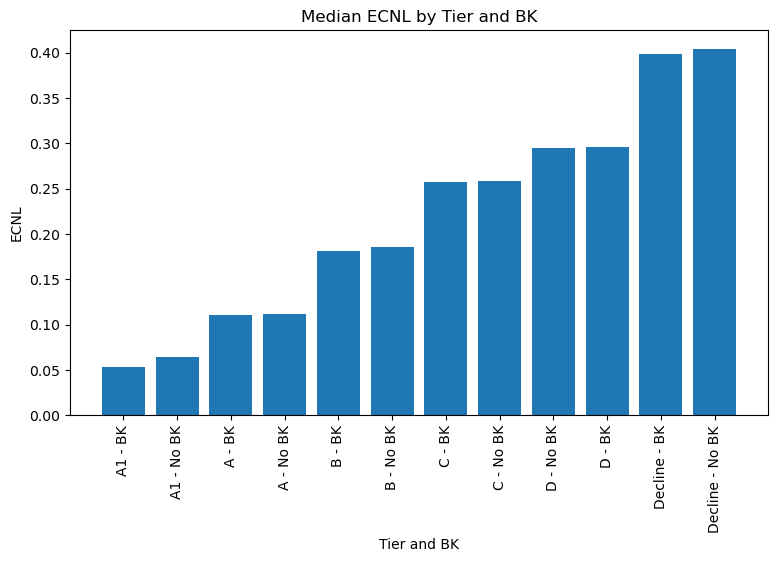

In [26]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Median ECNL by Tier and BK')
ax.set_xlabel('Tier and BK')
ax.set_ylabel('ECNL')
ax.bar(df_grouped['tier_bk'], df_grouped['fltDebtorScore'])
ax.set_xticklabels(df_grouped['tier_bk'], rotation=90)
plt.show()